# 05. Product Launches and Feature Rollouts

Product launches are causal interventions.

A team does not only want to know whether users who saw the new feature were more active. It wants to know what would have happened if the same users had not received the feature. That distinction matters because launches are rarely clean:

- high-intent users may discover the feature first,
- teams may ramp to healthier users before risky users,
- novelty effects can fade,
- guardrail metrics can move in the wrong direction,
- feature exposure may require users to enter a workflow,
- launch timing may coincide with seasonality, press, or other product changes.

This notebook treats product launch analysis as a causal decision workflow. We will simulate a feature-gated experiment, estimate launch impact, use CUPED-style variance reduction, diagnose trigger and rollout pitfalls, analyze a staggered rollout, and write a launch decision memo.

## Learning Goals

By the end of this notebook, you should be able to:

- Define product launch estimands: intention-to-treat, treatment-on-triggered, and rollout effects.
- Estimate A/B test effects on primary and guardrail metrics.
- Use pre-experiment covariates for variance reduction with CUPED.
- Explain why post-treatment trigger conditioning can bias feature analysis.
- Design ramp monitoring for staged rollout decisions.
- Analyze a staggered rollout with fixed effects and event-study diagnostics.
- Translate experiment evidence into a launch, ramp, rollback, or iterate decision.

## 1. Setup

We will use pandas, numpy, statsmodels, scipy, seaborn, matplotlib, and Graphviz.

In [1]:
import warnings

warnings.filterwarnings("ignore")

from IPython.display import Markdown, display
from graphviz import Digraph
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
import seaborn as sns
import statsmodels.formula.api as smf


rng = np.random.default_rng(20260430)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["figure.dpi"] = 130


def dollars(x, digits=0):
    return f"${x:,.{digits}f}"


def pct(x, digits=1):
    return f"{100 * x:.{digits}f}%"


def styled_table(df, money_cols=None, pct_cols=None, num_cols=None):
    money_cols = money_cols or []
    pct_cols = pct_cols or []
    num_cols = num_cols or []
    fmt = {}
    for col in money_cols:
        fmt[col] = lambda v: dollars(v, 2) if abs(v) < 100 else dollars(v, 0)
    for col in pct_cols:
        fmt[col] = lambda v: pct(v, 2)
    for col in num_cols:
        fmt[col] = lambda v: f"{v:,.3f}"
    return df.style.format(fmt)

## 2. Product Launches as Causal Questions

Let $W_i=1$ mean user $i$ is assigned to the new feature. Let $Y_i(1)$ be the outcome if the user receives the feature and $Y_i(0)$ the outcome if they do not.

The basic launch estimand is the average treatment effect:

$$
\tau = E[Y(1)-Y(0)]
$$

In an A/B test, assignment is randomized, so:

$$
\hat{\tau} = \bar{Y}_{W=1} - \bar{Y}_{W=0}
$$

For product launches, the estimand must be paired with the decision:

- **Ship:** primary metric improves and guardrails are safe.
- **Ramp slowly:** impact is promising but guardrails or uncertainty require caution.
- **Iterate:** primary metric is weak, but diagnostics identify fixable issues.
- **Rollback:** guardrails fail or user harm is likely.

Kohavi and Longbotham (2017) describe online controlled experiments and A/B testing as a central way to evaluate product changes. Deng, Kohavi, and Frasca (2013) discuss large-scale online controlled experiments as infrastructure for accelerating product innovation.

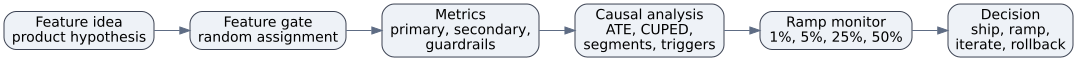

In [2]:
dot = Digraph("launch_decision_flow", format="svg")
dot.attr(rankdir="LR", bgcolor="transparent")
dot.attr("node", shape="box", style="rounded,filled", color="#3B4252", fillcolor="#EEF2F7", fontname="DejaVu Sans")
dot.attr("edge", color="#5E6C84", fontname="DejaVu Sans")

dot.node("idea", "Feature idea\nproduct hypothesis")
dot.node("gate", "Feature gate\nrandom assignment")
dot.node("metrics", "Metrics\nprimary, secondary,\nguardrails")
dot.node("analysis", "Causal analysis\nATE, CUPED,\nsegments, triggers")
dot.node("ramp", "Ramp monitor\n1%, 5%, 25%, 50%")
dot.node("decision", "Decision\nship, ramp,\niterate, rollback")

dot.edge("idea", "gate")
dot.edge("gate", "metrics")
dot.edge("metrics", "analysis")
dot.edge("analysis", "ramp")
dot.edge("ramp", "decision")

dot

A good launch analysis is not just a p-value. It connects the causal estimate to operational safety:

- What is the primary success metric?
- Which guardrails must not regress?
- Who is in the experiment population?
- Does the feature affect only triggered users?
- Are there novelty effects or ramp effects?
- Is the result large enough to matter?

## 3. Running Example: Workflow Assistant Launch

Imagine a SaaS company launching a new workflow assistant. The feature suggests next actions inside a project workspace.

Primary metric:

- completed tasks per user over 14 days.

Secondary metric:

- revenue per user over 14 days.

Guardrails:

- latency,
- error sessions,
- support ticket rate.

The feature is behind a feature flag. Users are randomly assigned before launch.

In [3]:
def simulate_feature_experiment(n=80_000, seed=501):
    local_rng = np.random.default_rng(seed)
    segments = local_rng.choice(
        ["new_user", "casual", "power_user", "enterprise"],
        size=n,
        p=[0.26, 0.36, 0.26, 0.12],
    )
    device = local_rng.choice(["desktop", "mobile"], size=n, p=[0.68, 0.32])
    region = local_rng.choice(["NA", "EU", "APAC", "LATAM"], size=n, p=[0.48, 0.24, 0.20, 0.08])

    tenure_days = np.clip(local_rng.gamma(shape=2.4, scale=70, size=n), 1, 900)
    base_activity = (
        2.2
        + 1.0 * (segments == "power_user")
        + 0.7 * (segments == "enterprise")
        - 0.6 * (segments == "new_user")
        + 0.35 * (device == "desktop")
    )
    pre_tasks_28 = local_rng.poisson(np.clip(base_activity * 6.0, 0.5, None), size=n)
    pre_revenue_28 = local_rng.gamma(shape=1.8 + 0.04 * pre_tasks_28, scale=12.0)
    pre_revenue_28 *= np.where(segments == "enterprise", 2.2, 1.0)
    pre_workflow_entries = local_rng.poisson(np.clip(0.18 * pre_tasks_28 + 0.8 * (segments == "power_user"), 0.1, None))

    treatment = local_rng.binomial(1, 0.50, size=n)

    baseline_tasks = (
        1.8
        + 0.18 * pre_tasks_28
        + 0.9 * (segments == "power_user")
        + 0.45 * (segments == "enterprise")
        - 0.35 * (segments == "new_user")
        + local_rng.normal(0, 1.35, size=n)
    )
    tasks0 = np.clip(baseline_tasks, 0, None)

    true_task_effect = (
        0.16
        + 0.20 * (segments == "new_user")
        + 0.24 * (segments == "power_user")
        + 0.05 * (segments == "casual")
        - 0.08 * (segments == "enterprise")
        + 0.025 * np.log1p(pre_workflow_entries)
        - 0.05 * (device == "mobile")
    )
    true_task_effect = np.clip(true_task_effect, -0.18, 0.70)
    tasks1 = np.clip(tasks0 + true_task_effect + local_rng.normal(0, 0.42, size=n), 0, None)

    revenue0 = np.clip(
        0.58 * pre_revenue_28
        + 6.5 * tasks0
        + local_rng.normal(0, 18, size=n),
        0,
        None,
    )
    revenue_effect = 5.0 * true_task_effect + 1.8 * (segments == "enterprise") - 1.0 * (device == "mobile")
    revenue1 = np.clip(revenue0 + revenue_effect + local_rng.normal(0, 10, size=n), 0, None)

    latency0 = np.clip(
        local_rng.normal(260, 45, size=n)
        + 42 * (device == "mobile")
        + 28 * (segments == "enterprise"),
        120,
        None,
    )
    latency1 = latency0 + 18 + 9 * (device == "mobile") + 8 * (segments == "enterprise") + local_rng.normal(0, 10, size=n)

    error_prob0 = np.clip(0.011 + 0.006 * (device == "mobile") + 0.005 * (segments == "enterprise"), 0, 0.08)
    error_prob1 = np.clip(error_prob0 + 0.0025 + 0.002 * (device == "mobile"), 0, 0.10)
    error0 = local_rng.binomial(1, error_prob0)
    error1 = local_rng.binomial(1, error_prob1)

    support_prob0 = np.clip(0.018 + 0.008 * (segments == "new_user") + 0.006 * (segments == "enterprise"), 0, 0.12)
    support_prob1 = np.clip(support_prob0 + 0.0015 + 0.002 * (segments == "enterprise") - 0.001 * (segments == "power_user"), 0, 0.14)
    support0 = local_rng.binomial(1, support_prob0)
    support1 = local_rng.binomial(1, support_prob1)

    post_trigger_prob0 = np.clip(0.18 + 0.03 * pre_workflow_entries + 0.10 * (segments == "power_user"), 0, 0.92)
    post_trigger_prob1 = np.clip(post_trigger_prob0 + 0.08 + 0.05 * (segments == "new_user"), 0, 0.97)
    trigger0 = local_rng.binomial(1, post_trigger_prob0)
    trigger1 = local_rng.binomial(1, post_trigger_prob1)

    df = pd.DataFrame(
        {
            "user_id": np.arange(n),
            "segment": segments,
            "device": device,
            "region": region,
            "tenure_days": tenure_days,
            "pre_tasks_28": pre_tasks_28,
            "pre_revenue_28": pre_revenue_28,
            "pre_workflow_entries": pre_workflow_entries,
            "pre_eligible": pre_workflow_entries > 0,
            "treatment": treatment,
            "tasks": np.where(treatment == 1, tasks1, tasks0),
            "revenue": np.where(treatment == 1, revenue1, revenue0),
            "latency_ms": np.where(treatment == 1, latency1, latency0),
            "error_session": np.where(treatment == 1, error1, error0),
            "support_ticket": np.where(treatment == 1, support1, support0),
            "post_triggered": np.where(treatment == 1, trigger1, trigger0).astype(bool),
            "tasks0": tasks0,
            "tasks1": tasks1,
            "revenue0": revenue0,
            "revenue1": revenue1,
            "true_task_effect": tasks1 - tasks0,
            "true_revenue_effect": revenue1 - revenue0,
            "latency0": latency0,
            "latency1": latency1,
        }
    )
    return df


experiment = simulate_feature_experiment()

display(experiment.head())
print(f"Rows: {len(experiment):,}")
print(f"Treatment share: {experiment['treatment'].mean():.1%}")
print(f"Pre-eligible share: {experiment['pre_eligible'].mean():.1%}")
print(f"Post-triggered share: {experiment['post_triggered'].mean():.1%}")

,user_id,segment,device,region,tenure_days,pre_tasks_28,pre_revenue_28,pre_workflow_entries,pre_eligible,treatment,...,support_ticket,post_triggered,tasks0,tasks1,revenue0,revenue1,true_task_effect,true_revenue_effect,latency0,latency1
0,0,enterprise,desktop,LATAM,192.450589,23,38.322484,3,True,1,...,0,False,5.608542,5.501997,47.790272,62.498816,-0.106544,14.708544,268.279113,305.940362
1,1,power_user,desktop,APAC,140.110967,13,12.293282,2,True,0,...,0,True,4.796311,4.611310,25.401722,22.861708,-0.185001,-2.540014,311.655479,334.841593
2,2,casual,desktop,NA,257.347367,16,40.515249,3,True,0,...,0,False,5.050517,4.532310,67.141106,94.385314,-0.518207,27.244207,239.150880,262.875029
3,3,casual,desktop,EU,121.991450,14,12.996367,1,True,1,...,0,False,4.720403,5.637329,56.556810,59.997941,0.916926,3.441131,239.084054,268.005398
4,4,power_user,desktop,APAC,120.111073,23,56.440391,10,True,0,...,0,True,6.338152,7.831232,36.707565,19.915867,1.493080,-16.791698,345.250497,371.843433


Rows: 80,000
Treatment share: 49.9%
Pre-eligible share: 91.6%
Post-triggered share: 34.3%


The simulated data includes both observed outcomes and hidden potential outcomes. In real product experiments, the hidden columns do not exist; they are included here so we can check what the estimators are trying to recover.

## 4. Balance Checks

Randomization should make treatment and control groups similar before launch. The first launch-readiness check is balance on pre-treatment variables.

In [4]:
balance = (
    experiment.groupby("treatment")
    .agg(
        users=("user_id", "size"),
        pre_tasks_28=("pre_tasks_28", "mean"),
        pre_revenue_28=("pre_revenue_28", "mean"),
        pre_workflow_entries=("pre_workflow_entries", "mean"),
        tenure_days=("tenure_days", "mean"),
        pre_eligible=("pre_eligible", "mean"),
    )
    .rename(index={0: "Control", 1: "Feature"})
    .reset_index(names="group")
)

display(
    styled_table(
        balance,
        money_cols=["pre_revenue_28"],
        pct_cols=["pre_eligible"],
        num_cols=["pre_tasks_28", "pre_workflow_entries", "tenure_days"],
    )
)

,group,users,pre_tasks_28,pre_revenue_28,pre_workflow_entries,tenure_days,pre_eligible
0,Control,40063,15.785,$33.55,3.066,168.099,91.87%
1,Feature,39937,15.734,$33.71,3.034,168.209,91.37%


Balance is not only a statistical ritual. It is an engineering check. Imbalance can indicate broken assignment, bot filtering differences, logging gaps, or feature flag leakage.

## 5. Primary and Guardrail Effects

Launch decisions usually use a metric stack:

- **Primary:** the metric the feature is designed to improve.
- **Secondary:** monetization, retention, or strategic metrics.
- **Guardrails:** metrics that should not regress, such as latency, errors, support tickets, abuse, or fairness.

We will estimate treatment-minus-control differences for each metric.

In [5]:
def diff_in_means(df, outcome, treatment_col="treatment"):
    treated = df[treatment_col].eq(1)
    y_t = df.loc[treated, outcome]
    y_c = df.loc[~treated, outcome]
    diff = y_t.mean() - y_c.mean()
    se = np.sqrt(y_t.var(ddof=1) / len(y_t) + y_c.var(ddof=1) / len(y_c))
    return diff, se, diff - 1.96 * se, diff + 1.96 * se, y_t.mean(), y_c.mean()


metric_specs = [
    ("tasks", "Primary: completed tasks", "higher"),
    ("revenue", "Secondary: revenue", "higher"),
    ("latency_ms", "Guardrail: latency ms", "lower"),
    ("error_session", "Guardrail: error session rate", "lower"),
    ("support_ticket", "Guardrail: support ticket rate", "lower"),
]

metric_rows = []
for metric, label, direction in metric_specs:
    diff, se, lo, hi, treat_mean, control_mean = diff_in_means(experiment, metric)
    metric_rows.append(
        {
            "metric": label,
            "direction": direction,
            "control_mean": control_mean,
            "treatment_mean": treat_mean,
            "effect": diff,
            "se": se,
            "ci_low": lo,
            "ci_high": hi,
        }
    )

metric_readout = pd.DataFrame(metric_rows)
display(metric_readout)

,metric,direction,control_mean,treatment_mean,effect,se,ci_low,ci_high
0,Primary: completed tasks,higher,4.850285,5.124616,0.274331,0.013701,0.247478,0.301184
1,Secondary: revenue,higher,51.087258,52.715917,1.628659,0.199102,1.238420,2.018898
2,Guardrail: latency ms,lower,276.814430,298.562601,21.748171,0.363369,21.035969,22.460374
3,Guardrail: error session rate,lower,0.013529,0.016726,0.003198,0.000863,0.001506,0.004889
4,Guardrail: support ticket rate,lower,0.020892,0.022085,0.001193,0.001025,-0.000817,0.003202


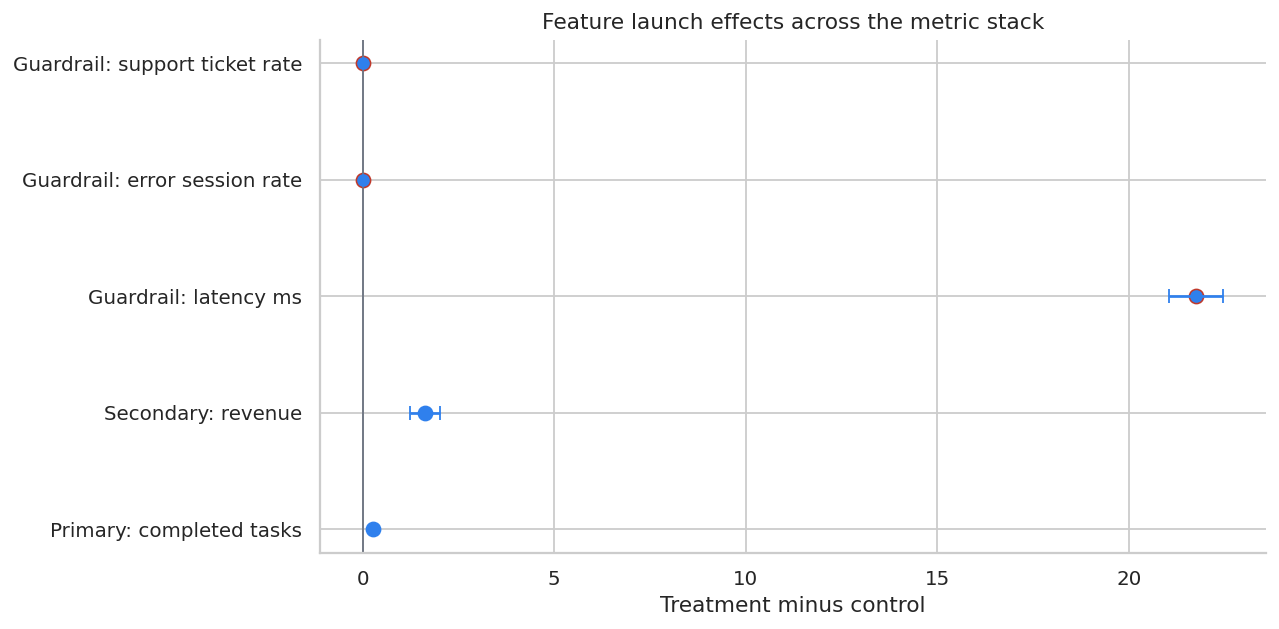

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_metrics = metric_readout.copy()
plot_metrics["y"] = np.arange(len(plot_metrics))
colors = np.where(plot_metrics["direction"].eq("higher"), "#2F80ED", "#C0392B")
ax.errorbar(
    plot_metrics["effect"],
    plot_metrics["y"],
    xerr=[plot_metrics["effect"] - plot_metrics["ci_low"], plot_metrics["ci_high"] - plot_metrics["effect"]],
    fmt="o",
    color="#2F80ED",
    capsize=4,
)
for y, color in zip(plot_metrics["y"], colors):
    ax.scatter(plot_metrics.loc[plot_metrics["y"].eq(y), "effect"], [y], color=color, s=60)
ax.axvline(0, color="#6B7280", linewidth=1)
ax.set_yticks(plot_metrics["y"])
ax.set_yticklabels(plot_metrics["metric"])
ax.set_title("Feature launch effects across the metric stack")
ax.set_xlabel("Treatment minus control")
plt.tight_layout()
plt.show()

The primary metric can move in the right direction while guardrails also move. A launch decision requires both effect size and safety interpretation.

## 6. CUPED-Style Variance Reduction

Online experiments often have pre-experiment data. If a pre-period covariate is predictive of the outcome and not affected by treatment, it can reduce variance.

Deng, Xu, Kohavi, and Walker (2013) introduced CUPED, controlled experiments using pre-experiment data, for improving sensitivity in online controlled experiments.

For outcome $Y$ and pre-period covariate $X$, define:

$$
Y^{adj}_i = Y_i - \theta(X_i-\bar{X})
$$

where:

$$
\theta = \frac{Cov(Y,X)}{Var(X)}
$$

Then estimate the treatment effect on $Y^{adj}$. Because $X$ is measured before treatment, this adjustment does not adjust away the treatment effect.

In [7]:
def cuped_adjustment(df, outcome, covariate):
    theta = np.cov(df[outcome], df[covariate], ddof=1)[0, 1] / np.var(df[covariate], ddof=1)
    adjusted = df[outcome] - theta * (df[covariate] - df[covariate].mean())
    return adjusted, theta


experiment["tasks_cuped"] = cuped_adjustment(experiment, "tasks", "pre_tasks_28")[0]
theta_tasks = cuped_adjustment(experiment, "tasks", "pre_tasks_28")[1]

unadj = diff_in_means(experiment, "tasks")
adj = diff_in_means(experiment, "tasks_cuped")

cuped_readout = pd.DataFrame(
    [
        {
            "estimator": "Unadjusted difference in means",
            "effect": unadj[0],
            "se": unadj[1],
            "ci_low": unadj[2],
            "ci_high": unadj[3],
        },
        {
            "estimator": "CUPED-adjusted",
            "effect": adj[0],
            "se": adj[1],
            "ci_low": adj[2],
            "ci_high": adj[3],
        },
    ]
)
cuped_readout["se_reduction_vs_unadjusted"] = 1 - cuped_readout["se"] / cuped_readout.loc[0, "se"]

display(styled_table(cuped_readout, num_cols=["effect", "se", "ci_low", "ci_high"], pct_cols=["se_reduction_vs_unadjusted"]))
print(f"CUPED theta for pre_tasks_28: {theta_tasks:.3f}")

,estimator,effect,se,ci_low,ci_high,se_reduction_vs_unadjusted
0,Unadjusted difference in means,0.274,0.014,0.247,0.301,0.00%
1,CUPED-adjusted,0.286,0.010,0.267,0.306,26.20%


CUPED theta for pre_tasks_28: 0.238


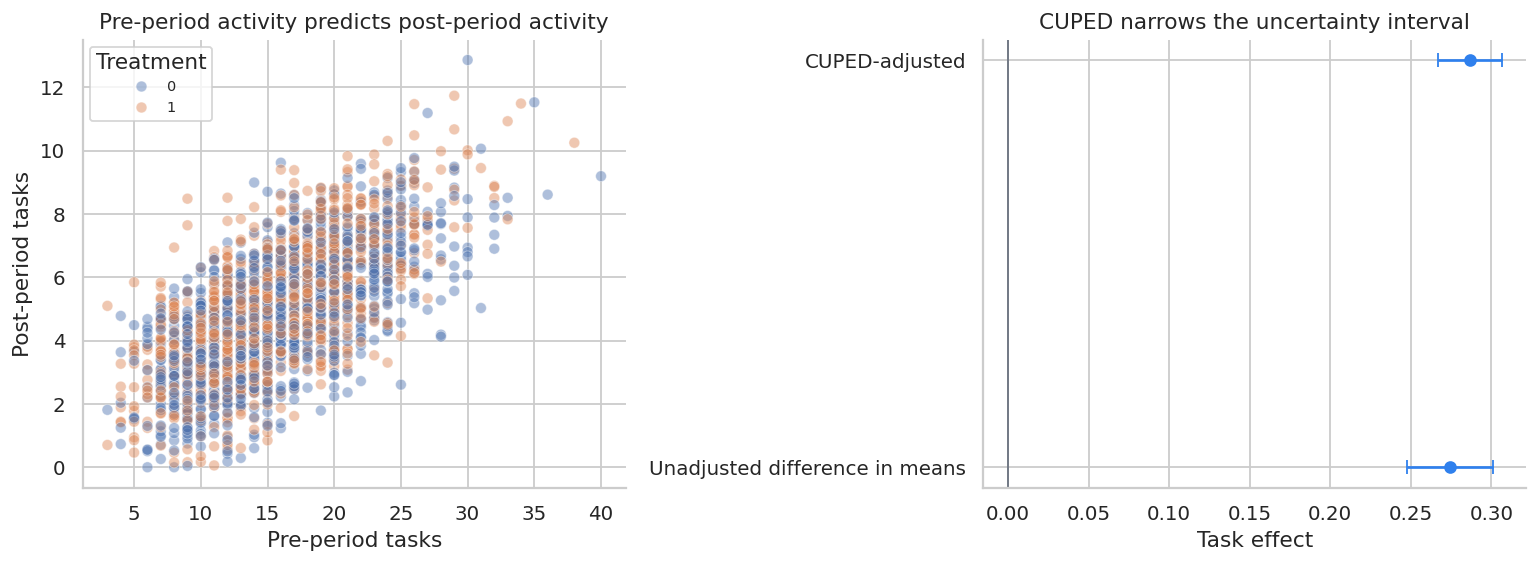

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.scatterplot(
    data=experiment.sample(2500, random_state=1),
    x="pre_tasks_28",
    y="tasks",
    hue="treatment",
    alpha=0.45,
    ax=axes[0],
)
axes[0].set_title("Pre-period activity predicts post-period activity")
axes[0].set_xlabel("Pre-period tasks")
axes[0].set_ylabel("Post-period tasks")
axes[0].legend(title="Treatment", fontsize=8)

plot_cuped = cuped_readout.copy()
plot_cuped["y"] = np.arange(len(plot_cuped))
axes[1].errorbar(
    plot_cuped["effect"],
    plot_cuped["y"],
    xerr=[plot_cuped["effect"] - plot_cuped["ci_low"], plot_cuped["ci_high"] - plot_cuped["effect"]],
    fmt="o",
    capsize=4,
    color="#2F80ED",
)
axes[1].axvline(0, color="#6B7280", linewidth=1)
axes[1].set_yticks(plot_cuped["y"])
axes[1].set_yticklabels(plot_cuped["estimator"])
axes[1].set_title("CUPED narrows the uncertainty interval")
axes[1].set_xlabel("Task effect")

plt.tight_layout()
plt.show()

CUPED is especially useful for mature products where true effects are small but pre-period behavior strongly predicts post-period behavior.

## 7. Triggered Analysis and a Common Trap

Many product features only affect users who enter a workflow. A natural question is:

> Should we analyze all randomized users or only triggered users?

The safest primary estimand is usually the intention-to-treat effect over all randomized users:

$$
ITT = E[Y\mid W=1] - E[Y\mid W=0]
$$

If trigger eligibility is known before treatment, we can also analyze the pre-eligible subgroup. But conditioning on post-treatment triggering can be biased because treatment itself may change who triggers.

In [9]:
itt_effect = diff_in_means(experiment, "tasks")[0]
pre_eligible_effect = diff_in_means(experiment.query("pre_eligible"), "tasks")[0]

post_triggered = experiment.query("post_triggered").copy()
post_triggered_effect = diff_in_means(post_triggered, "tasks")[0]

trigger_readout = pd.DataFrame(
    [
        {
            "analysis_population": "All randomized users (ITT)",
            "users": len(experiment),
            "treatment_share": experiment["treatment"].mean(),
            "task_effect": itt_effect,
            "true_mean_effect": experiment["true_task_effect"].mean(),
        },
        {
            "analysis_population": "Pre-eligible users",
            "users": experiment["pre_eligible"].sum(),
            "treatment_share": experiment.query("pre_eligible")["treatment"].mean(),
            "task_effect": pre_eligible_effect,
            "true_mean_effect": experiment.query("pre_eligible")["true_task_effect"].mean(),
        },
        {
            "analysis_population": "Post-triggered users only",
            "users": len(post_triggered),
            "treatment_share": post_triggered["treatment"].mean(),
            "task_effect": post_triggered_effect,
            "true_mean_effect": post_triggered["true_task_effect"].mean(),
        },
    ]
)

display(styled_table(trigger_readout, pct_cols=["treatment_share"], num_cols=["task_effect", "true_mean_effect"]))

,analysis_population,users,treatment_share,task_effect,true_mean_effect
0,All randomized users (ITT),80000,49.92%,0.274,0.297
1,Pre-eligible users,73297,49.78%,0.283,0.299
2,Post-triggered users only,27478,56.23%,0.170,0.310


The post-triggered estimate can look different because the feature changes who enters the triggered population. That is a selection problem. For launch decisions, define triggered populations using pre-treatment eligibility or use causal methods designed for noncompliance and triggering.

## 8. Segment Readout

Product leaders often need to know where the feature works. Segment effects are useful, but they should be interpreted as exploratory unless pre-specified.

In [10]:
segment_rows = []
for segment, g in experiment.groupby("segment"):
    diff, se, lo, hi, treat_mean, control_mean = diff_in_means(g, "tasks")
    rev_diff = diff_in_means(g, "revenue")[0]
    latency_diff = diff_in_means(g, "latency_ms")[0]
    segment_rows.append(
        {
            "segment": segment,
            "users": len(g),
            "control_tasks": control_mean,
            "treatment_tasks": treat_mean,
            "task_effect": diff,
            "ci_low": lo,
            "ci_high": hi,
            "revenue_effect": rev_diff,
            "latency_effect_ms": latency_diff,
            "true_task_effect": g["true_task_effect"].mean(),
        }
    )

segment_effects = pd.DataFrame(segment_rows).sort_values("task_effect", ascending=False)

display(
    styled_table(
        segment_effects,
        money_cols=["revenue_effect"],
        num_cols=["control_tasks", "treatment_tasks", "task_effect", "ci_low", "ci_high", "latency_effect_ms", "true_task_effect"],
    )
)

,segment,users,control_tasks,treatment_tasks,task_effect,ci_low,ci_high,revenue_effect,latency_effect_ms,true_task_effect
3,power_user,20701,6.399,6.860,0.461,0.416,0.505,$2.27,19.977,0.422
2,new_user,20758,3.464,3.821,0.357,0.316,0.398,$2.07,21.218,0.375
0,casual,28950,4.450,4.629,0.179,0.144,0.215,$1.17,20.730,0.221
1,enterprise,9591,5.667,5.746,0.079,0.015,0.142,$1.30,29.693,0.087


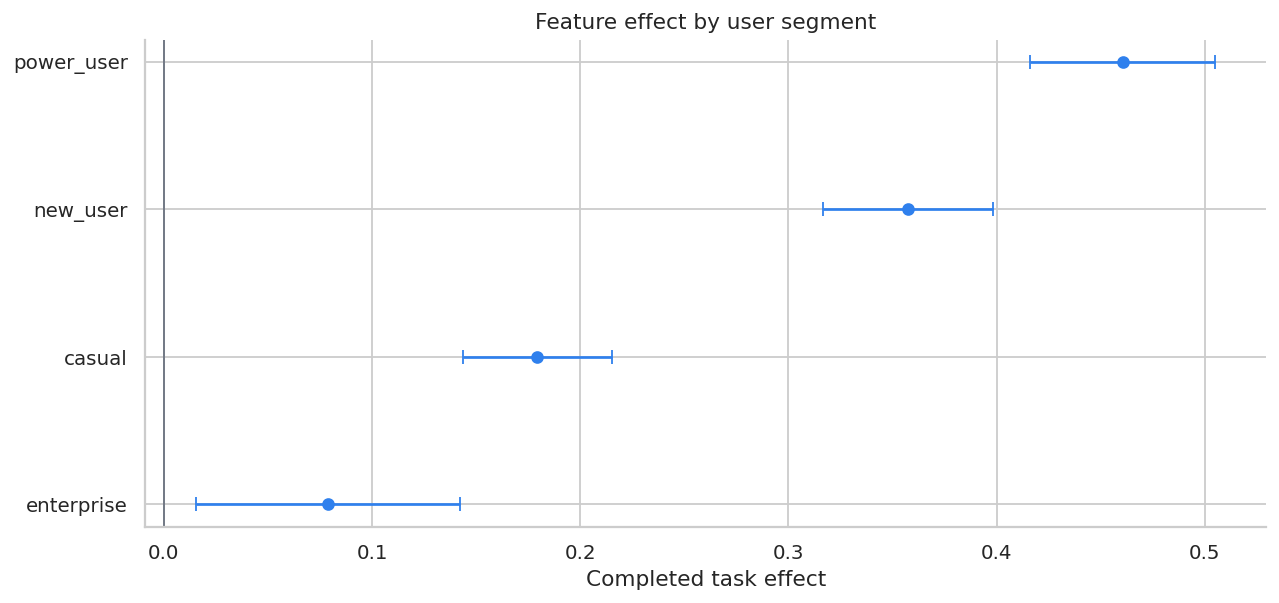

In [11]:
fig, ax = plt.subplots(figsize=(10, 4.8))
plot_segments = segment_effects.sort_values("task_effect")
ax.errorbar(
    plot_segments["task_effect"],
    plot_segments["segment"],
    xerr=[
        plot_segments["task_effect"] - plot_segments["ci_low"],
        plot_segments["ci_high"] - plot_segments["task_effect"],
    ],
    fmt="o",
    color="#2F80ED",
    capsize=4,
)
ax.axvline(0, color="#6B7280", linewidth=1)
ax.set_title("Feature effect by user segment")
ax.set_xlabel("Completed task effect")
plt.tight_layout()
plt.show()

Segment readouts help decide whether to launch to everyone, exclude a segment, or continue iteration for a segment with weak value or worse guardrails.

## 9. Ramp Monitoring

Even after a successful A/B test, many teams do not jump from 0% to 100%. They ramp:

- 1% to catch severe issues,
- 5% to validate telemetry and infrastructure,
- 25% to observe broader behavior,
- 50% or 100% once guardrails are stable.

Ramp monitoring is not the same as causal estimation. It is operational risk management.

In [12]:
def simulate_ramp_monitoring(seed=777):
    local_rng = np.random.default_rng(seed)
    days = np.arange(1, 22)
    ramp_share = np.select(
        [days <= 3, days <= 7, days <= 12, days <= 17, days > 17],
        [0.01, 0.05, 0.25, 0.50, 1.00],
    )
    base_users = local_rng.poisson(90_000, size=len(days))
    treated_users = (base_users * ramp_share).astype(int)
    control_users = base_users - treated_users

    novelty = np.exp(-(days - 1) / 8)
    true_task_lift = 0.24 + 0.10 * novelty
    observed_task_lift = true_task_lift + local_rng.normal(0, 0.035, size=len(days)) / np.sqrt(np.maximum(ramp_share, 0.01))
    p95_latency_delta = 18 + 8 * ramp_share + local_rng.normal(0, 5, size=len(days))
    error_delta_pp = 0.18 + 0.10 * ramp_share + local_rng.normal(0, 0.05, size=len(days))
    support_delta_pp = 0.05 + 0.06 * ramp_share + local_rng.normal(0, 0.035, size=len(days))

    return pd.DataFrame(
        {
            "day": days,
            "ramp_share": ramp_share,
            "treated_users": treated_users,
            "control_users": control_users,
            "observed_task_lift": observed_task_lift,
            "p95_latency_delta_ms": p95_latency_delta,
            "error_delta_pp": error_delta_pp,
            "support_delta_pp": support_delta_pp,
        }
    )


ramp = simulate_ramp_monitoring()
display(ramp.head(10))

,day,ramp_share,treated_users,control_users,observed_task_lift,p95_latency_delta_ms,error_delta_pp,support_delta_pp
0,1,0.01,900,89195,0.610436,20.020495,0.062154,0.063294
1,2,0.01,900,89185,0.744781,10.113467,0.111259,0.083497
2,3,0.01,897,88814,-0.326481,14.258752,0.127019,0.084766
3,4,0.05,4502,85556,0.624167,22.273590,0.167390,0.085190
4,5,0.05,4510,85703,0.246873,22.409248,0.118277,0.021161
5,6,0.05,4468,84906,0.180948,11.984551,0.176068,-0.007992
6,7,0.05,4511,85724,0.253426,20.074111,0.172743,0.067359
7,8,0.25,22544,67634,0.156559,11.122229,0.329729,0.027060
8,9,0.25,22483,67450,0.188526,25.961659,0.261177,0.029114
9,10,0.25,22434,67305,0.304390,14.824928,0.202617,0.075105


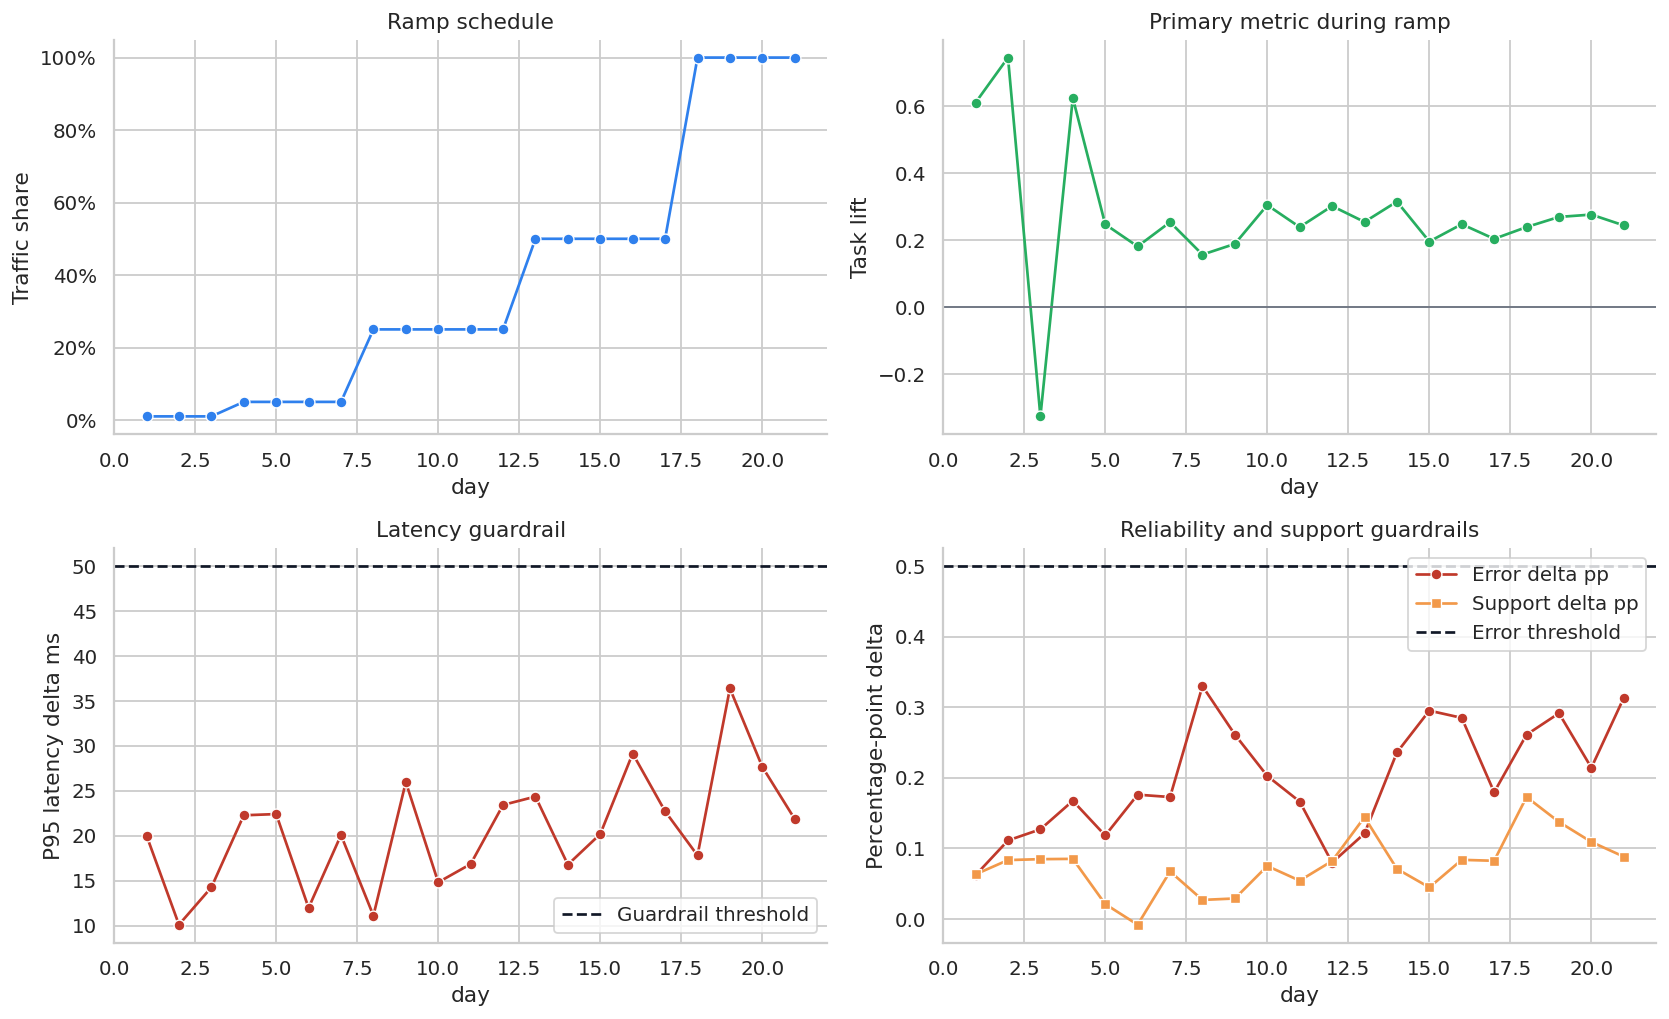

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

sns.lineplot(data=ramp, x="day", y="ramp_share", marker="o", ax=axes[0, 0], color="#2F80ED")
axes[0, 0].set_title("Ramp schedule")
axes[0, 0].set_ylabel("Traffic share")
axes[0, 0].yaxis.set_major_formatter(lambda x, pos: f"{100*x:.0f}%")

sns.lineplot(data=ramp, x="day", y="observed_task_lift", marker="o", ax=axes[0, 1], color="#27AE60")
axes[0, 1].axhline(0, color="#6B7280", linewidth=1)
axes[0, 1].set_title("Primary metric during ramp")
axes[0, 1].set_ylabel("Task lift")

sns.lineplot(data=ramp, x="day", y="p95_latency_delta_ms", marker="o", ax=axes[1, 0], color="#C0392B")
axes[1, 0].axhline(50, color="#111827", linestyle="--", label="Guardrail threshold")
axes[1, 0].set_title("Latency guardrail")
axes[1, 0].set_ylabel("P95 latency delta ms")
axes[1, 0].legend()

sns.lineplot(data=ramp, x="day", y="error_delta_pp", marker="o", ax=axes[1, 1], color="#C0392B", label="Error delta pp")
sns.lineplot(data=ramp, x="day", y="support_delta_pp", marker="s", ax=axes[1, 1], color="#F2994A", label="Support delta pp")
axes[1, 1].axhline(0.50, color="#111827", linestyle="--", label="Error threshold")
axes[1, 1].set_title("Reliability and support guardrails")
axes[1, 1].set_ylabel("Percentage-point delta")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

Ramp dashboards should be boring by design. If the primary metric is positive but reliability guardrails deteriorate as ramp share grows, the correct decision may be to pause or roll back.

## 10. Staggered Rollout Analysis

Sometimes a feature cannot be randomized at the user level. Enterprise products often roll out by organization, workspace, country, or infrastructure cluster.

If units adopt at different times and remain treated, this is a staggered adoption design. Athey and Imbens (2022) discuss design-based analysis in difference-in-differences settings with staggered adoption. Goodman-Bacon (2021) shows that standard two-way fixed-effects difference-in-differences can have subtle weighting issues when treatment timing varies.

The practical lesson:

- randomize rollout timing if possible,
- keep some holdout units,
- inspect pre-trends and event-time effects,
- be cautious with a single all-in-one regression when effects vary over time.

In [14]:
def simulate_staggered_rollout(n_orgs=64, n_weeks=28, seed=909):
    local_rng = np.random.default_rng(seed)
    orgs = [f"Org_{i:02d}" for i in range(n_orgs)]
    org_size = local_rng.lognormal(mean=8.2, sigma=0.45, size=n_orgs)
    org_maturity = local_rng.beta(2.5, 2.0, size=n_orgs)
    org_trend = local_rng.normal(0.04, 0.04, size=n_orgs)

    rollout_options = [12, 16, 20, np.inf]
    rollout_probs = [0.25, 0.25, 0.25, 0.25]
    rollout_week = local_rng.choice(rollout_options, size=n_orgs, p=rollout_probs)

    rows = []
    for i, org in enumerate(orgs):
        for week in range(n_weeks):
            treated = int(week >= rollout_week[i])
            event_time = week - rollout_week[i] if np.isfinite(rollout_week[i]) else np.nan
            seasonal = 0.40 * np.sin(2 * np.pi * week / 13)
            baseline = (
                34
                + 4.5 * org_maturity[i]
                + 0.0015 * org_size[i]
                + org_trend[i] * week
                + seasonal
                + local_rng.normal(0, 1.7)
            )
            ramp = 0 if not treated else min(max((event_time + 1) / 5, 0), 1)
            treatment_effect = treated * ramp * (2.6 + 2.0 * org_maturity[i])
            outcome = baseline + treatment_effect
            rows.append(
                {
                    "org": org,
                    "week": week,
                    "org_size": org_size[i],
                    "org_maturity": org_maturity[i],
                    "rollout_week": rollout_week[i],
                    "ever_treated": np.isfinite(rollout_week[i]),
                    "treated": treated,
                    "event_time": event_time,
                    "weekly_tasks_per_100_users": outcome,
                    "true_effect": treatment_effect,
                }
            )

    return pd.DataFrame(rows)


rollout = simulate_staggered_rollout()

display(rollout.head())
print(f"Org-weeks: {len(rollout):,}")
print(f"Organizations: {rollout['org'].nunique()}")
print("Rollout cohorts:")
print(rollout.groupby("org")["rollout_week"].first().value_counts(dropna=False).sort_index().to_string())

,org,week,org_size,org_maturity,rollout_week,ever_treated,treated,event_time,weekly_tasks_per_100_users,true_effect
0,Org_00,0,2548.750243,0.907066,20.0,True,0,-20.0,42.540368,0.0
1,Org_00,1,2548.750243,0.907066,20.0,True,0,-19.0,45.093856,0.0
2,Org_00,2,2548.750243,0.907066,20.0,True,0,-18.0,40.789517,0.0
3,Org_00,3,2548.750243,0.907066,20.0,True,0,-17.0,42.766060,0.0
4,Org_00,4,2548.750243,0.907066,20.0,True,0,-16.0,39.639876,0.0


Org-weeks: 1,792
Organizations: 64
Rollout cohorts:
rollout_week
12.0    12
16.0    21
20.0    12
inf     19


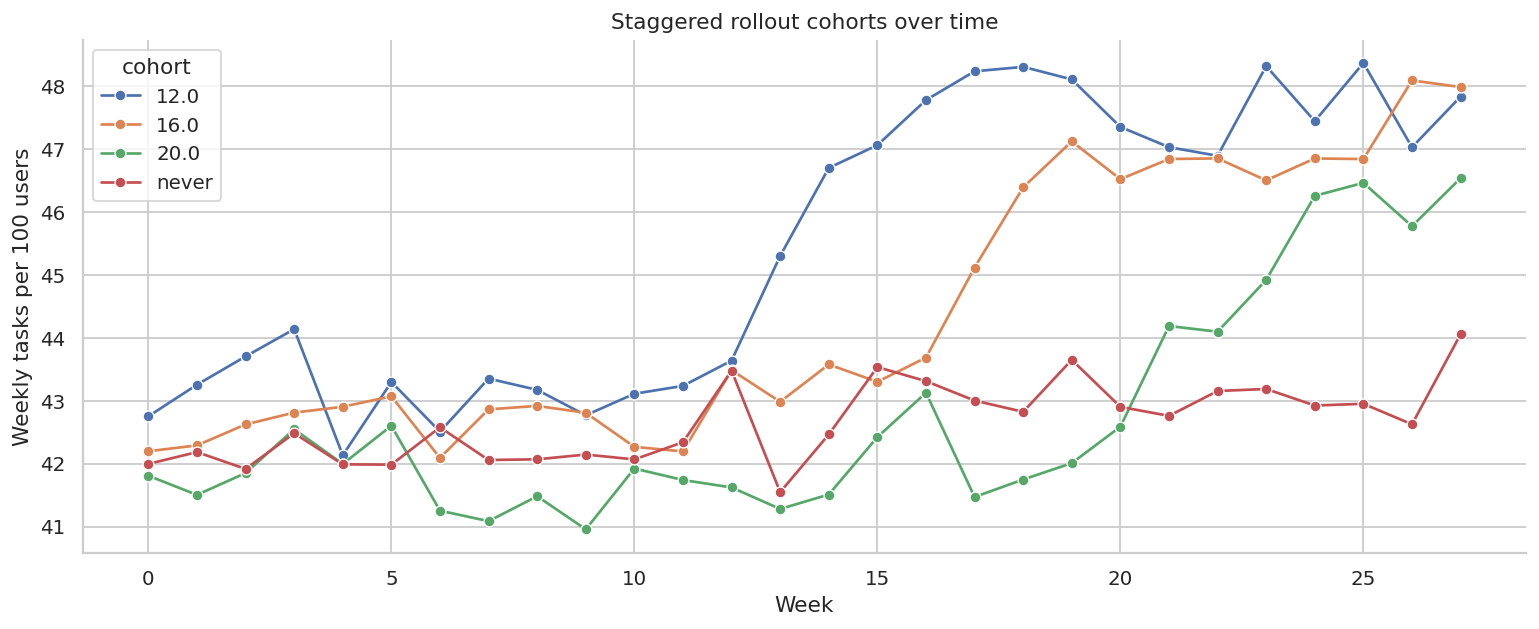

In [15]:
weekly_rollout = (
    rollout.assign(cohort=lambda d: np.where(d["ever_treated"], d["rollout_week"].astype(str), "never"))
    .groupby(["week", "cohort"])
    .agg(metric=("weekly_tasks_per_100_users", "mean"))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(data=weekly_rollout, x="week", y="metric", hue="cohort", marker="o", ax=ax)
ax.set_title("Staggered rollout cohorts over time")
ax.set_xlabel("Week")
ax.set_ylabel("Weekly tasks per 100 users")
plt.tight_layout()
plt.show()

The plot shows why rollout analysis is not just before-versus-after. Cohorts launch at different times, have different maturity, and may have different trends.

In [16]:
before_after = (
    rollout.query("ever_treated")
    .assign(post=lambda d: d["treated"])
    .groupby("post")["weekly_tasks_per_100_users"]
    .mean()
)
naive_before_after = before_after.loc[1] - before_after.loc[0]

twfe = smf.ols(
    "weekly_tasks_per_100_users ~ treated + C(org) + C(week)",
    data=rollout,
).fit(cov_type="cluster", cov_kwds={"groups": rollout["org"]})

true_att = rollout.loc[rollout["treated"].eq(1), "true_effect"].mean()

rollout_readout = pd.DataFrame(
    [
        {
            "estimator": "Naive treated before-after",
            "estimate": naive_before_after,
            "ci_low": np.nan,
            "ci_high": np.nan,
        },
        {
            "estimator": "TWFE DiD",
            "estimate": twfe.params["treated"],
            "ci_low": twfe.conf_int().loc["treated", 0],
            "ci_high": twfe.conf_int().loc["treated", 1],
        },
        {
            "estimator": "True ATT among treated org-weeks",
            "estimate": true_att,
            "ci_low": np.nan,
            "ci_high": np.nan,
        },
    ]
)

display(styled_table(rollout_readout, num_cols=["estimate", "ci_low", "ci_high"]))

,estimator,estimate,ci_low,ci_high
0,Naive treated before-after,4.020,nan,nan
1,TWFE DiD,2.760,2.303,3.217
2,True ATT among treated org-weeks,3.128,nan,nan


The naive before-after estimate mixes the feature with time trends and cohort composition. Fixed effects are better, but event-study diagnostics are still essential.

In [17]:
event_window = list(range(-6, 9))
event_window.remove(-1)

event_data = rollout.copy()
for k in event_window:
    name = f"event_m{abs(k)}" if k < 0 else f"event_p{k}"
    event_data[name] = ((event_data["event_time"] == k) & event_data["ever_treated"]).astype(int)

event_terms = " + ".join([f"event_m{abs(k)}" if k < 0 else f"event_p{k}" for k in event_window])
event_model = smf.ols(
    f"weekly_tasks_per_100_users ~ {event_terms} + C(org) + C(week)",
    data=event_data,
).fit(cov_type="cluster", cov_kwds={"groups": event_data["org"]})

event_rows = []
for k in event_window:
    name = f"event_m{abs(k)}" if k < 0 else f"event_p{k}"
    event_rows.append(
        {
            "event_time": k,
            "estimate": event_model.params[name],
            "ci_low": event_model.conf_int().loc[name, 0],
            "ci_high": event_model.conf_int().loc[name, 1],
        }
    )
event_estimates = pd.DataFrame(event_rows)

display(styled_table(event_estimates, num_cols=["estimate", "ci_low", "ci_high"]))

,event_time,estimate,ci_low,ci_high
0,-6,-1.293,-1.866,-0.720
1,-5,-0.692,-1.426,0.042
2,-4,-0.577,-1.241,0.087
3,-3,-0.851,-1.436,-0.267
4,-2,-1.124,-1.826,-0.423
5,0,-1.068,-1.872,-0.263
6,1,0.835,0.218,1.452
7,2,1.306,0.609,2.003
8,3,1.795,1.120,2.470
9,4,2.054,1.348,2.760


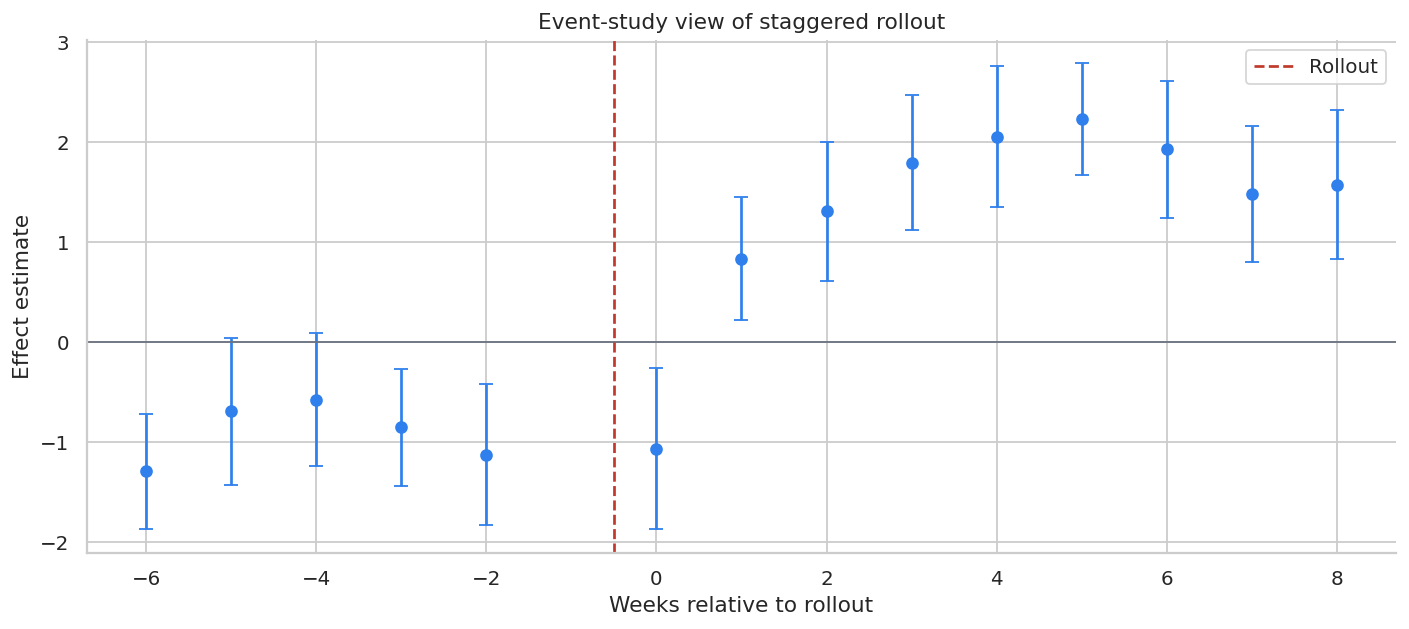

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.errorbar(
    event_estimates["event_time"],
    event_estimates["estimate"],
    yerr=[
        event_estimates["estimate"] - event_estimates["ci_low"],
        event_estimates["ci_high"] - event_estimates["estimate"],
    ],
    fmt="o",
    capsize=4,
    color="#2F80ED",
)
ax.axhline(0, color="#6B7280", linewidth=1)
ax.axvline(-0.5, color="#C0392B", linestyle="--", label="Rollout")
ax.set_title("Event-study view of staggered rollout")
ax.set_xlabel("Weeks relative to rollout")
ax.set_ylabel("Effect estimate")
ax.legend()
plt.tight_layout()
plt.show()

A credible event study should show little movement before rollout and a plausible pattern after rollout. If pre-period coefficients move sharply, the rollout design may not support a causal claim.

## 11. Launch Threat Model

Product launches have failure modes that are both statistical and operational.

In [19]:
threats = pd.DataFrame(
    [
        {
            "threat": "Broken randomization",
            "symptom": "Treatment and control differ before launch.",
            "diagnostic": "Balance checks and sample ratio mismatch checks.",
            "mitigation": "Audit assignment, bucketing, bot filters, and eligibility logic.",
        },
        {
            "threat": "Trigger selection bias",
            "symptom": "Only post-triggered users are analyzed.",
            "diagnostic": "Compare ITT, pre-eligible, and post-triggered analyses.",
            "mitigation": "Define trigger eligibility before treatment or use trigger-aware methods.",
        },
        {
            "threat": "Novelty effects",
            "symptom": "Early lift fades over time.",
            "diagnostic": "Daily cumulative effects and cohort-by-day plots.",
            "mitigation": "Run full-week tests and monitor post-launch retention.",
        },
        {
            "threat": "Guardrail regression",
            "symptom": "Primary metric improves but latency, errors, or support worsen.",
            "diagnostic": "Pre-specified guardrail thresholds.",
            "mitigation": "Pause, ramp slowly, or fix reliability before launch.",
        },
        {
            "threat": "Concurrent experiments",
            "symptom": "Another launch interacts with the feature.",
            "diagnostic": "Experiment registry and interaction checks.",
            "mitigation": "Mutual exclusion, layered randomization, or interaction modeling.",
        },
        {
            "threat": "Staggered rollout confounding",
            "symptom": "Early cohorts differ from late cohorts.",
            "diagnostic": "Pre-trends, event studies, and holdout cohorts.",
            "mitigation": "Randomize rollout order and preserve never-treated holdouts.",
        },
        {
            "threat": "Metric gaming",
            "symptom": "Feature increases shallow activity but not durable value.",
            "diagnostic": "Retention, quality, satisfaction, and revenue guardrails.",
            "mitigation": "Use a metric stack, not a single activity metric.",
        },
    ]
)

display(threats)

,threat,symptom,diagnostic,mitigation
0,Broken randomization,Treatment and control differ before launch.,Balance checks and sample ratio mismatch checks.,"Audit assignment, bucketing, bot filters, and ..."
1,Trigger selection bias,Only post-triggered users are analyzed.,"Compare ITT, pre-eligible, and post-triggered ...",Define trigger eligibility before treatment or...
2,Novelty effects,Early lift fades over time.,Daily cumulative effects and cohort-by-day plots.,Run full-week tests and monitor post-launch re...
3,Guardrail regression,"Primary metric improves but latency, errors, o...",Pre-specified guardrail thresholds.,"Pause, ramp slowly, or fix reliability before ..."
4,Concurrent experiments,Another launch interacts with the feature.,Experiment registry and interaction checks.,"Mutual exclusion, layered randomization, or in..."
5,Staggered rollout confounding,Early cohorts differ from late cohorts.,"Pre-trends, event studies, and holdout cohorts.",Randomize rollout order and preserve never-tre...
6,Metric gaming,Feature increases shallow activity but not dur...,"Retention, quality, satisfaction, and revenue ...","Use a metric stack, not a single activity metric."


## 12. Decision Memo Template

The final launch memo should be concise and decision-facing. Here is a template using the simulated A/B test.

In [20]:
primary = metric_readout.query("metric == 'Primary: completed tasks'").iloc[0]
revenue = metric_readout.query("metric == 'Secondary: revenue'").iloc[0]
latency = metric_readout.query("metric == 'Guardrail: latency ms'").iloc[0]
error = metric_readout.query("metric == 'Guardrail: error session rate'").iloc[0]
support = metric_readout.query("metric == 'Guardrail: support ticket rate'").iloc[0]

guardrail_pass = (
    latency["ci_high"] < 50
    and error["ci_high"] < 0.005
    and support["ci_high"] < 0.003
)

decision = "Ramp to 50% with continued guardrail monitoring" if guardrail_pass and primary["ci_low"] > 0 else "Pause or iterate before broad rollout"

memo = f'''
### Product Launch Readout

**Decision:** {decision}.

**Design:** User-level randomized feature-gate experiment with 50/50 assignment.

**Primary metric:** Completed tasks per user over 14 days.

**Primary effect:** {primary["effect"]:.3f} tasks per user, 95% CI [{primary["ci_low"]:.3f}, {primary["ci_high"]:.3f}].

**CUPED-adjusted primary effect:** {adj[0]:.3f} tasks per user, 95% CI [{adj[2]:.3f}, {adj[3]:.3f}].

**Revenue effect:** {dollars(revenue["effect"], 2)} per user, 95% CI [{dollars(revenue["ci_low"], 2)}, {dollars(revenue["ci_high"], 2)}].

**Latency guardrail:** {latency["effect"]:.1f} ms, 95% CI [{latency["ci_low"]:.1f}, {latency["ci_high"]:.1f}].

**Error-session guardrail:** {pct(error["effect"], 2)} percentage-point equivalent, 95% CI [{pct(error["ci_low"], 2)}, {pct(error["ci_high"], 2)}].

**Support-ticket guardrail:** {pct(support["effect"], 2)} percentage-point equivalent, 95% CI [{pct(support["ci_low"], 2)}, {pct(support["ci_high"], 2)}].

**Recommendation:** Keep the feature behind a ramp gate, continue monitoring latency and support, and run a segment-specific follow-up for enterprise users.

**Caveats:** Do not use post-triggered-only estimates as the primary launch estimate; maintain a holdout through the ramp to detect novelty decay.
'''

display(Markdown(memo))


### Product Launch Readout

**Decision:** Pause or iterate before broad rollout.

**Design:** User-level randomized feature-gate experiment with 50/50 assignment.

**Primary metric:** Completed tasks per user over 14 days.

**Primary effect:** 0.274 tasks per user, 95% CI [0.247, 0.301].

**CUPED-adjusted primary effect:** 0.286 tasks per user, 95% CI [0.267, 0.306].

**Revenue effect:** $1.63 per user, 95% CI [$1.24, $2.02].

**Latency guardrail:** 21.7 ms, 95% CI [21.0, 22.5].

**Error-session guardrail:** 0.32% percentage-point equivalent, 95% CI [0.15%, 0.49%].

**Support-ticket guardrail:** 0.12% percentage-point equivalent, 95% CI [-0.08%, 0.32%].

**Recommendation:** Keep the feature behind a ramp gate, continue monitoring latency and support, and run a segment-specific follow-up for enterprise users.

**Caveats:** Do not use post-triggered-only estimates as the primary launch estimate; maintain a holdout through the ramp to detect novelty decay.


The memo separates the causal evidence from the launch operation. That is the standard you want in industry: the model answers the causal question, and the rollout plan manages the risk.

## 13. Practical Workflow

A professional product-launch causal workflow usually follows this sequence:

1. Define the product hypothesis and primary metric.
2. Define guardrails and rollback thresholds before launch.
3. Randomize assignment using a durable feature gate.
4. Check sample ratio mismatch and pre-treatment balance.
5. Estimate primary, secondary, and guardrail effects.
6. Use pre-experiment data for variance reduction when appropriate.
7. Report ITT as the primary estimate; use triggered analyses carefully.
8. Inspect segment effects and novelty effects.
9. Ramp gradually with operational dashboards.
10. Preserve holdouts or randomized rollout order for post-launch measurement.
11. Convert the readout into ship, ramp, iterate, or rollback.

## Hands-On Extensions

Try extending this notebook in the following ways:

- Add sample-ratio-mismatch testing.
- Add multiple concurrent experiments and interaction checks.
- Use cluster randomization at workspace level instead of user-level randomization.
- Add retention outcomes measured 30 days after launch.
- Estimate treatment effects by device and region with shrinkage.
- Compare TWFE with cohort-specific DiD estimates in the staggered rollout.
- Build a launch dashboard with primary, guardrail, and ramp metrics.

## Key Takeaways

- Product launches are causal interventions, not just descriptive metric changes.
- The safest primary A/B estimand is usually intention-to-treat over all randomized users.
- CUPED can materially improve sensitivity when pre-period metrics predict post-period outcomes.
- Post-treatment trigger conditioning can bias feature analyses.
- Guardrails are part of the decision, not secondary decoration.
- Staggered rollouts need pre-trend and event-study diagnostics.
- A launch readout should recommend ship, ramp, iterate, or rollback with explicit evidence.

## References

Athey, S., & Imbens, G. W. (2022). Design-based analysis in difference-in-differences settings with staggered adoption. *Journal of Econometrics, 226*(1), 62-79. https://doi.org/10.1016/j.jeconom.2020.10.012

Deng, A., Kohavi, R., & Frasca, B. (2013). Online controlled experiments at large scale. *Proceedings of the 19th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, 1168-1176. https://doi.org/10.1145/2487575.2488217

Deng, A., Xu, Y., Kohavi, R., & Walker, T. (2013). Improving the sensitivity of online controlled experiments by utilizing pre-experiment data. *Proceedings of the Sixth ACM International Conference on Web Search and Data Mining*, 123-132. https://doi.org/10.1145/2433396.2433413

Goodman-Bacon, A. (2021). Difference-in-differences with variation in treatment timing. *Journal of Econometrics, 225*(2), 254-277. https://doi.org/10.1016/j.jeconom.2021.03.014

Kohavi, R., & Longbotham, R. (2017). Online controlled experiments and A/B testing. In *Encyclopedia of Machine Learning and Data Mining* (pp. 922-929). Springer. https://doi.org/10.1007/978-1-4899-7687-1_891

Liu, C. H. B., & Chamberlain, B. P. (2018). Online controlled experiments for personalised e-commerce strategies: Design, challenges, and pitfalls. *arXiv*. https://doi.org/10.48550/arxiv.1803.06258